# 🌧️📊 Monthly microphysical variables ☁️💧

This section presents the monthly distributions of precipitation microphysical variables, obtained from instruments across each study region.

Includes:

- 💧 Mass-weighted mean diameter ($D_m$)  
- 🌧️ Concentration parameter ($N_w$)  
- ☁️ Liquid water content (LWC)  

Each figure allows analysis of temporal variability and the characteristics of the drop size distribution (DSD) at a monthly scale. 🌦️

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import sys
import os
import glob
import numpy as np
import pandas as pd
import dask.dataframe as dd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker  # Import minor locator ticker
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as patches
from re import split
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import skew

from scipy import stats
from scipy.stats import norm, gamma, logistic, t, lognorm, expon, betaprime
# from scipy.special import gamma

from scipy.optimize import curve_fit

import calendar

# from dask_jobqueue import SLURMCluster

# from dask.distributed import Client, progress
from IPython.display import Image
from dask.distributed import Client
import folium

import warnings

warnings.filterwarnings('ignore')

import seaborn as sns
# import hvplot.xarray

import Functions as Func

In [ ]:
# 📦 Load precipitation events dataset (Zarr format)
# Source: SIATA data processed for station 77
# The dataset contains filtered microphysical variables (Dm, Nw, LWC, etc.)

ds_2 = xr.open_zarr(r"C:\Users\juanp\Documents\Universidad\Trabajo_de_Grado_Isabel\Datos_Solicitados_SIATA_JPC\resultados\Zarr\77_events.zarr")

# 👀 Inspect dataset structure (dimensions, variables, coordinates)
ds_2

<xarray.Dataset> Size: 6GB
Dimensions:       (time: 766500, diameter: 22, velocity: 20)
Coordinates:
  * time          (time) datetime64[ns] 6MB 2014-01-05T15:46:31 ... 2025-04-2...
  * diameter      (diameter) float64 176B 0.125 0.25 0.375 0.5 ... 7.0 7.5 8.0
  * velocity      (velocity) float64 160B 0.1 0.2 0.4 0.6 ... 7.4 8.2 9.0 10.0
Data variables: (12/19)
    Client        (time) <U1 3MB dask.array<chunksize=(10000,), meta=np.ndarray>
    MOR           (time) float64 6MB dask.array<chunksize=(10000,), meta=np.ndarray>
    Synop_Code    (time) <U1 3MB dask.array<chunksize=(10000,), meta=np.ndarray>
    d_m_filt      (time) float64 6MB dask.array<chunksize=(10000,), meta=np.ndarray>
    lwc_filt      (time) float64 6MB dask.array<chunksize=(10000,), meta=np.ndarray>
    n_t           (time) float64 6MB dask.array<chunksize=(10000,), meta=np.ndarray>
    ...            ...
    raw_filtrada  (time, diameter, velocity) float64 3GB dask.array<chunksize=(10000, 22, 20), meta=np.ndarray>
    ref           (time) float64 6MB dask.array<chunksize=(10000,), meta=np.ndarray>
    ref_filt      (time) float64 6MB dask.array<chunksize=(10000,), meta=np.ndarray>
    rl_int        (time) float64 6MB dask.array<chunksize=(10000,), meta=np.ndarray>
    rs_int        (time) float64 6MB dask.array<chunksize=(10000,), meta=np.ndarray>
    vd            (diameter) float64 176B dask.array<chunksize=(22,), meta=np.ndarray>
Attributes:
    institution:  SIATA / Universidad del Quindío
    references:   {'[1]': 'https://doi.org/10.1175/JTECH-D-13-00174.1', '[2]'...
    title:        Thies Disdrometer Precipitation Dataset

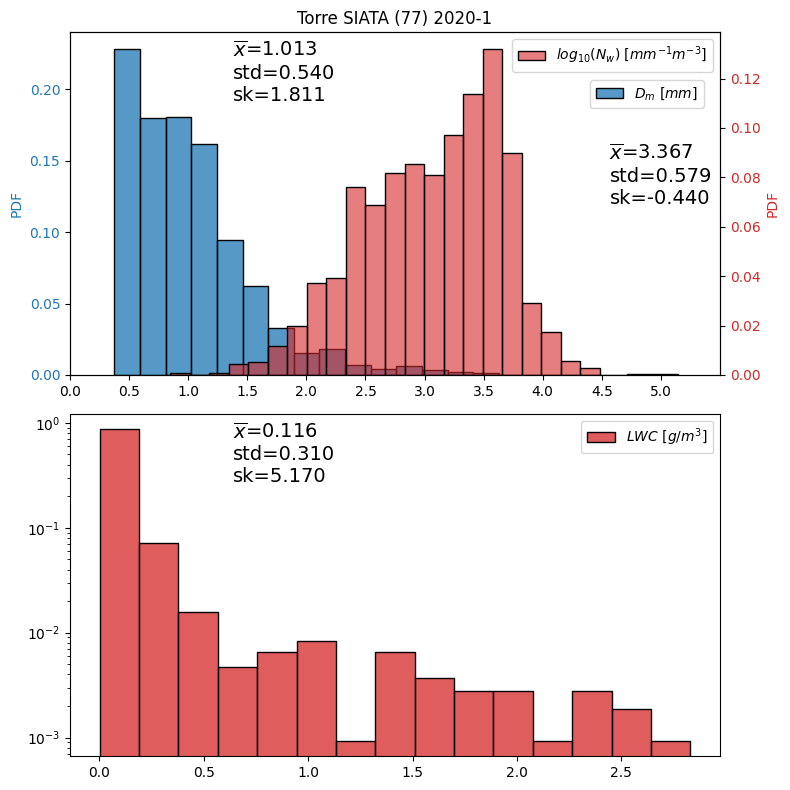

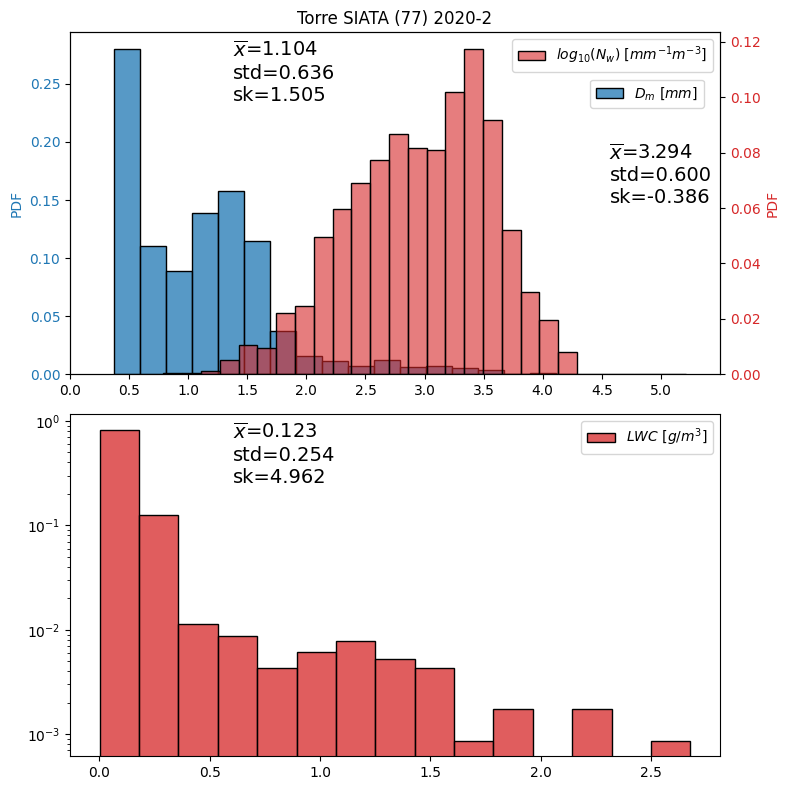

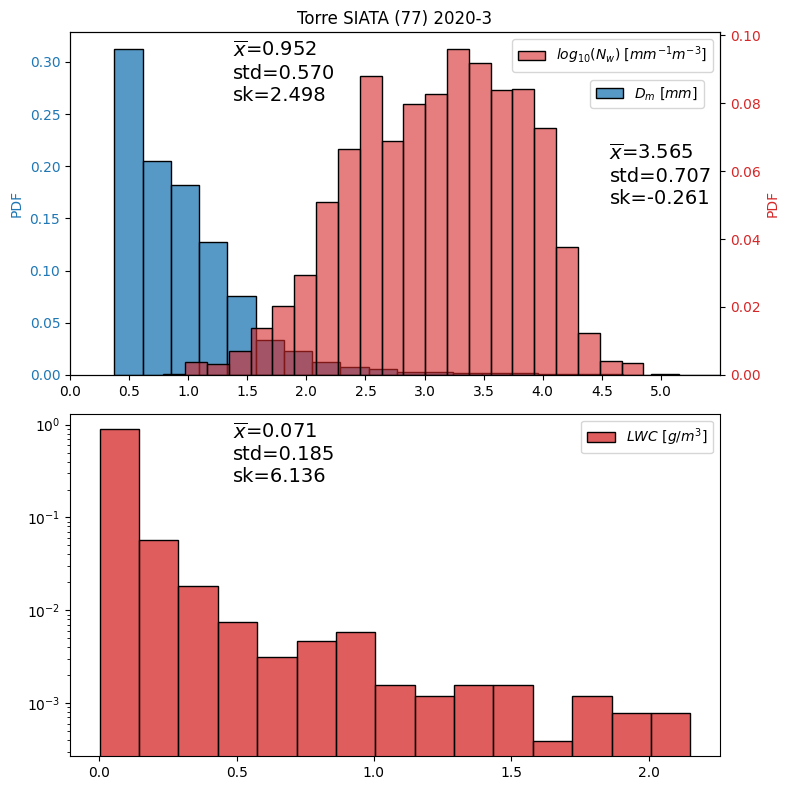

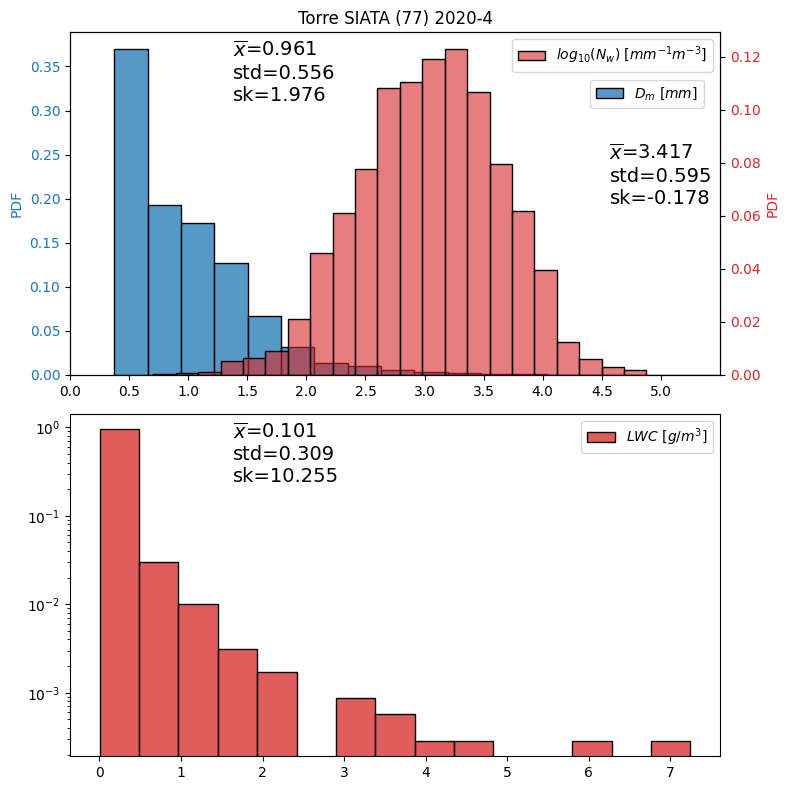

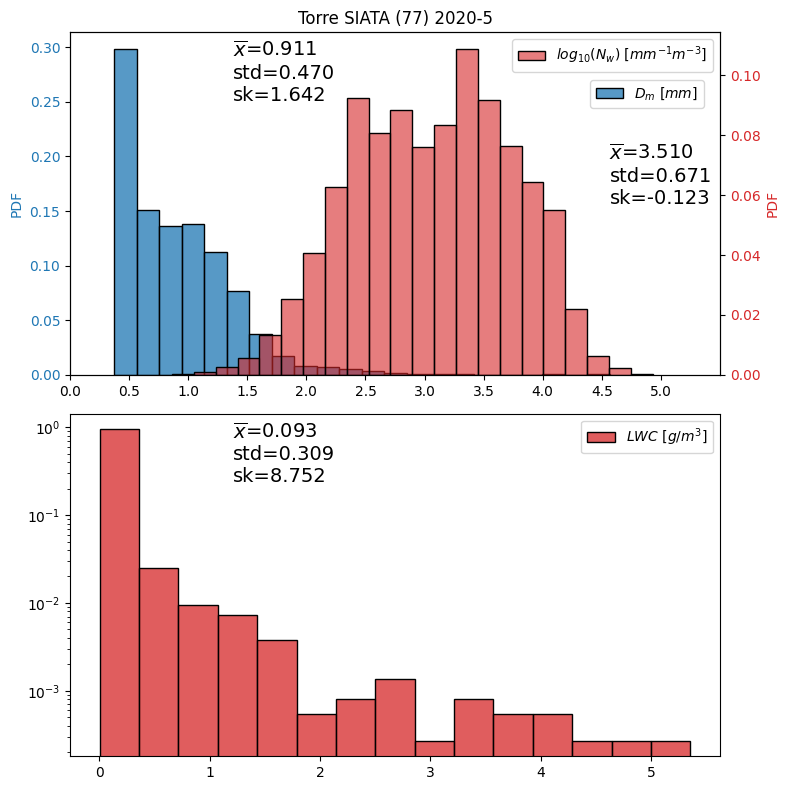

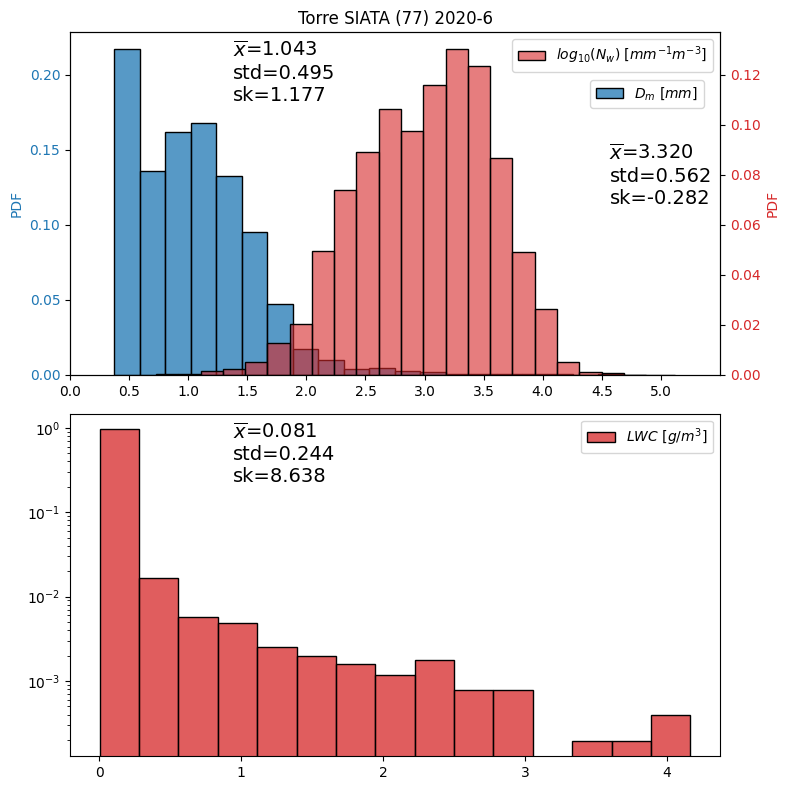

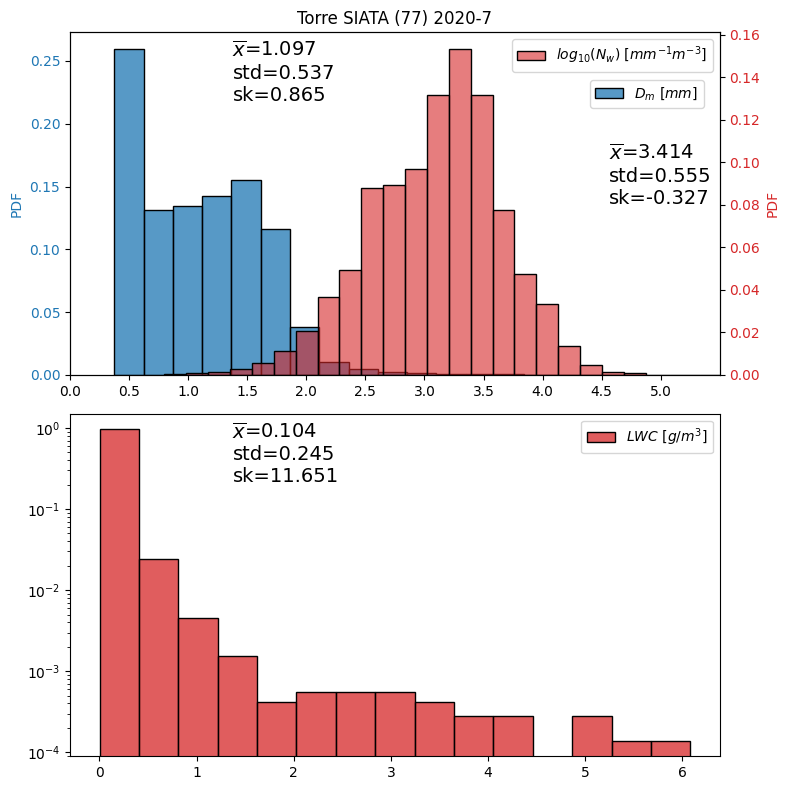

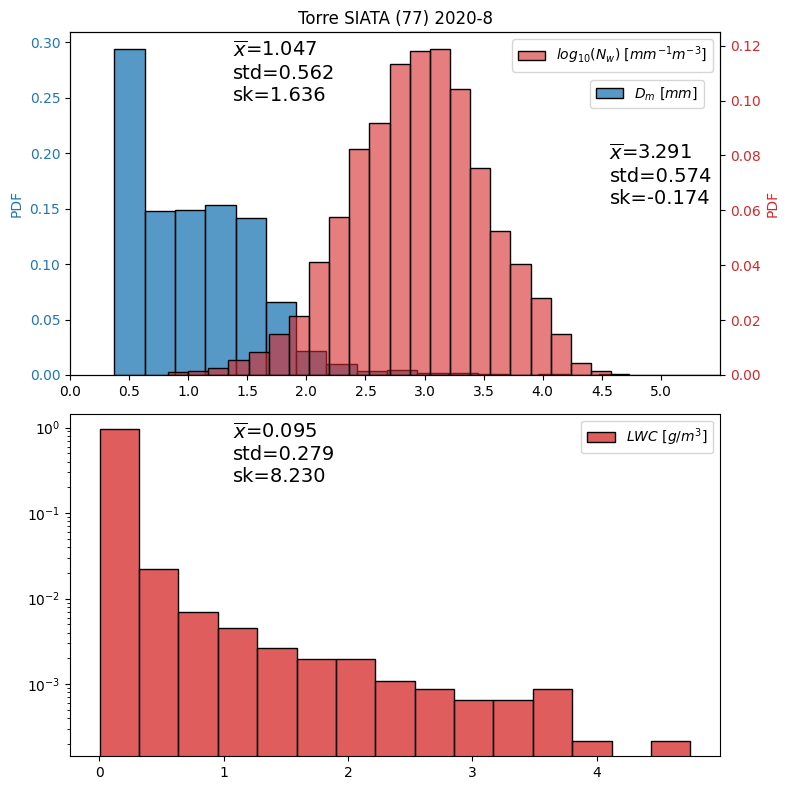

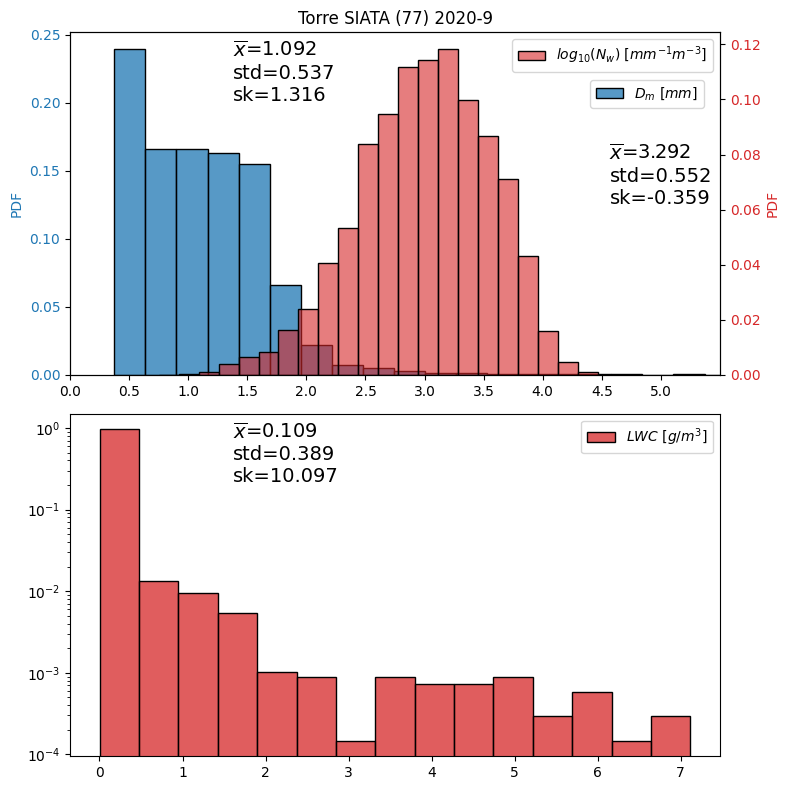

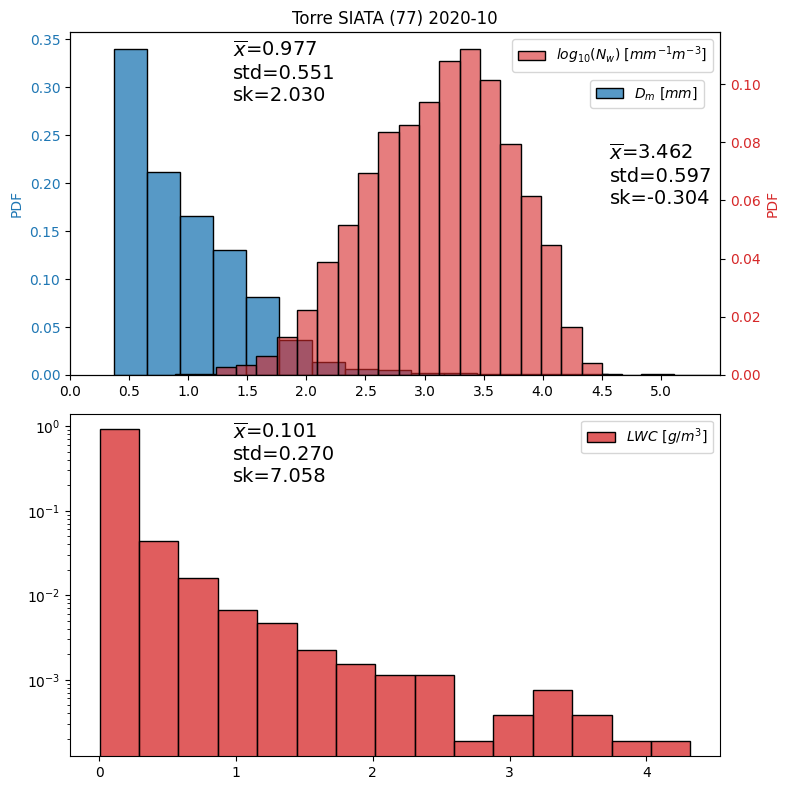

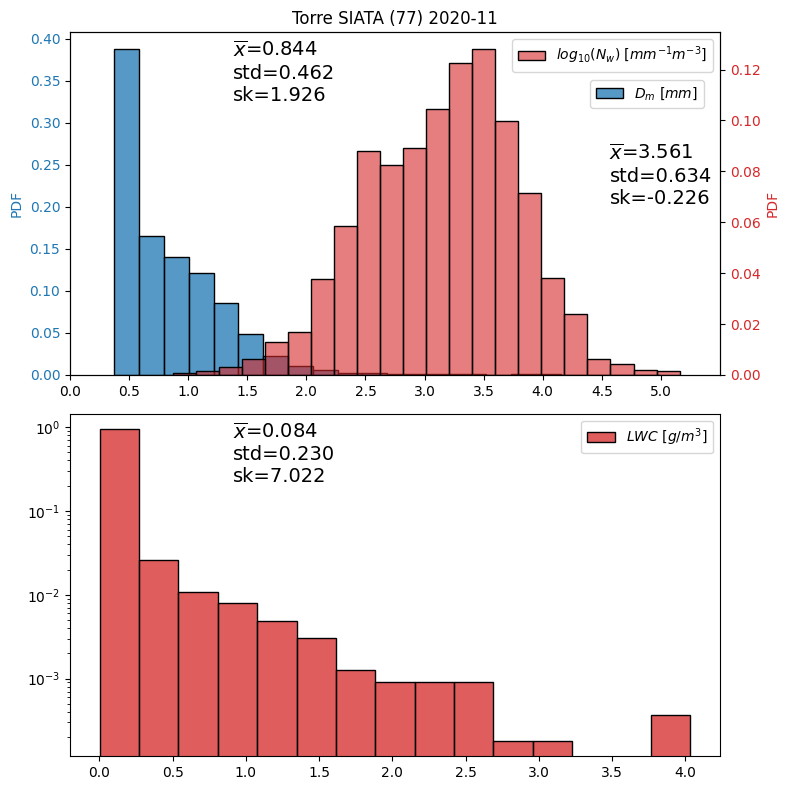

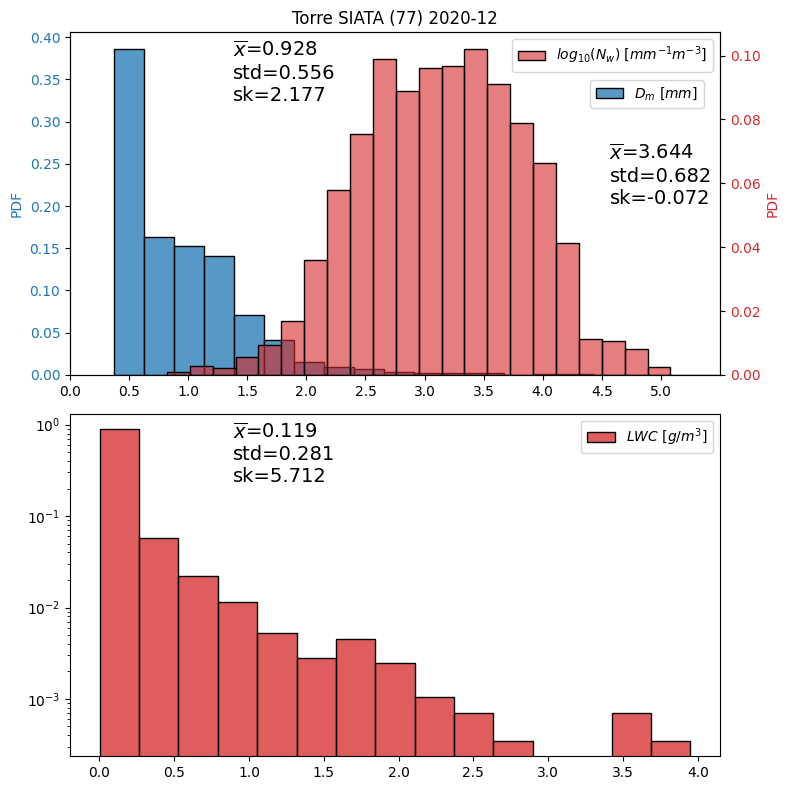

In [ ]:
# 📅 Define monthly time labels for the year 2020
month = ['2020-1', '2020-2', '2020-3', '2020-4', '2020-5', '2020-6',
         '2020-7', '2020-8', '2020-9', '2020-10', '2020-11', '2020-12']

# 📁 Define output directory where the PDF will be saved
ruta = r"C:\Users\juanp\Documents\Universidad\Trabajo_de_Grado_Isabel\Articulo_Trabajo_Grado"

# Create directory if it does not exist
os.makedirs(ruta, exist_ok=True)

# 📄 Create a multi-page PDF file to store all monthly figures
with PdfPages(os.path.join(ruta, 'Torre_SIATA_Mensual_2020.pdf')) as pdf:

    # 🔁 Loop over each month
    for i in month:

        # 📊 --- Compute statistical moments ---
        # Mean, standard deviation, and skewness for each variable

        mean_dm = ds_2.d_m_filt.loc[i].mean().values
        std_dm = ds_2.d_m_filt.loc[i].std().values
        sk_dm = skew(ds_2.d_m_filt.loc[i].values, nan_policy='omit')

        mean_nw = np.log10(ds_2.n_w_filt.loc[i].mean().values)
        std_nw = np.log10(ds_2.n_w_filt.loc[i]).std().values
        sk_nw = skew(np.log10(ds_2.n_w_filt.loc[i].values), nan_policy='omit')

        mean_lwc = ds_2.lwc_filt.loc[i].mean().values
        std_lwc = ds_2.lwc_filt.loc[i].std().values
        sk_lwc = skew(ds_2.lwc_filt.loc[i].values, nan_policy='omit')

        # 🖼️ Create figure with two vertically stacked subplots
        fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=False)

        # 🌧️ --- Subplot 1: Dm and Nw distributions ---

        # Histogram of mass-weighted mean diameter (Dm)
        sns.histplot(ds_2.d_m_filt.loc[i], bins=22, stat="probability",
                     ax=axs[0], color='tab:blue', label='$D_m\ [mm]$')

        axs[0].set_title('Torre SIATA (77) ' + i)

        # 📌 Annotate Dm statistics
        axs[0].text(0.25, 0.8,
                    f"$\\overline{{x}}$={mean_dm:.3f}\nstd={std_dm:.3f}\nsk={sk_dm:.3f}",
                    transform=axs[0].transAxes,
                    fontsize=14)

        # 📌 Annotate Nw statistics
        axs[0].text(0.83, 0.5,
                    f"$\\overline{{x}}$={mean_nw:.3f}\nstd={std_nw:.3f}\nsk={sk_nw:.3f}",
                    transform=axs[0].transAxes,
                    fontsize=14)

        axs[0].set_ylabel('PDF', color='tab:blue')
        axs[0].tick_params(axis='y', labelcolor='tab:blue')
        axs[0].set_xlim(0, 5.5)
        axs[0].set_xticks(np.arange(0, 5.5, 0.5))
        axs[0].legend(loc=(0.8, 0.78))

        # 🔄 Create secondary y-axis for Nw
        ax2 = axs[0].twinx()

        # Histogram of log10(Nw)
        sns.histplot(np.log10(ds_2.n_w_filt.loc[i]), bins=22, stat="probability",
                     ax=ax2, label='$log_{10}(N_w)\ [mm^{-1}m^{-3}]$',
                     color='tab:red', alpha=0.6)

        ax2.set_ylabel('PDF', color='tab:red')
        ax2.tick_params(axis='y', labelcolor='tab:red')
        ax2.legend(loc='upper right')

        # 🌧️ --- Subplot 2: LWC distribution ---

        sns.histplot(ds_2.lwc_filt.loc[i], bins=15, stat="probability",
                     ax=axs[1], color='tab:red', label='$LWC\ [g/m^3]$')

        # 📌 Annotate LWC statistics
        axs[1].text(0.25, 0.8,
                    f"$\\overline{{x}}$={mean_lwc:.3f}\nstd={std_lwc:.3f}\nsk={sk_lwc:.3f}",
                    transform=axs[1].transAxes,
                    fontsize=14)

        axs[1].set_ylabel('')
        axs[1].set_yscale('log')
        axs[1].legend()

        # 🔧 Adjust layout to prevent overlap
        plt.tight_layout()

        # 💾 Save current figure as a new page in the PDF
        pdf.savefig(fig)

        # 👀 Display figure (optional in batch processing)
        plt.show()